# Piece-wise linear potential on a quad mesh with square interface 

In [3]:
import ddr_tools as ddr #custom module
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact #interactive plots
import os
from matplotlib import ticker
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import NullFormatter
from scipy.sparse.linalg import gmres
import meshio

#### adpated routines 

In [6]:
def load_quad_mesh(filename):
    """
    Loads and parses a 2D mesh in msh format

    Parameters:
    - filename: path to the mesh file

    Returns:
    - Mesh object
    """
    # LOAD MESH:
    mesh_file_path = filename
    mesh = meshio.read(mesh_file_path)
    # face2node connectivity
    faces = mesh.cells[1].data # quads are element 1 of list
    # node coordinates
    coords = mesh.points
    # adjust type of faces
    faces = faces.astype(int)
    # Sizes
    Nfaces_init = faces.shape[0]
    Npoints_init = coords.shape[0]
    Nfaces = Nfaces_init
    Npoints = Npoints_init
    # dummy cut_faces (no cut faces, so all 0)
    cut_faces = np.zeros(Nfaces)
    # side_mask
    side_mask = -1*np.ones(Nfaces)
    # boundary mask, code:
    bnd_mask = np.zeros(Npoints_init)
    mesh = ddr.Mesh (faces, Nfaces, Nfaces_init, coords, Npoints, Npoints_init, cut_faces, side_mask, bnd_mask,\
                     no_intf_edges = np.zeros(10), no_points_per_face = 4)
    # no_intf_edges is dummy, not used
    return mesh
    
mesh = load_quad_mesh("square_quads_L1_N16.msh")
N = 16  # elements per side

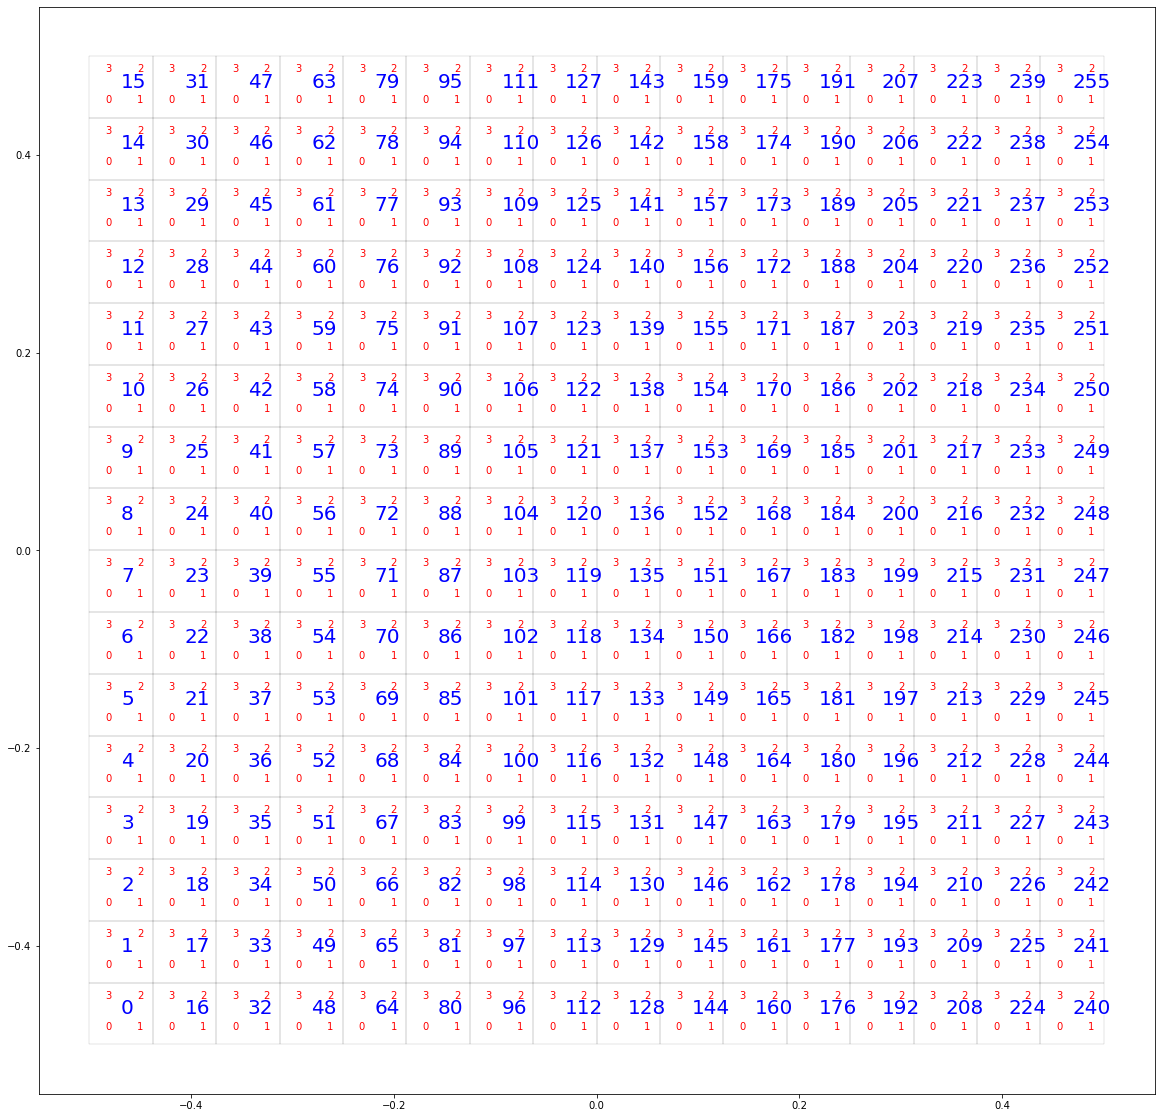

In [7]:
def visualize_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    for ifa in range(mesh.Nfaces):
        nvert = 4
        for ino in range(nvert):
            # draw edges
            p1 = mesh.coords[mesh.faces[ifa,ino],:]
            p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
            dx = p2-p1
            xx = [p1[0],p2[0]]
            yy = [p1[1],p2[1]]
            ax.plot(xx,yy,'k', linewidth=0.1)
            bary = ddr.barycenter(mesh,ifa)
            text_pos = bary+0.5*(p1-bary)
            text= str(ino)
            ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='red')
        # write face number
        text_pos = ddr.barycenter(mesh,ifa)
        text= str(ifa)
        ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='blue')

visualize_mesh(mesh)

In [8]:
# function to fill gamma_edges, assign side
# auxiliary arrays with same length of gamma_edges which 
# tell which edge is cut
def complete_mesh_info (quad_mesh, N):
    N_sq_in = N/2 # cells per side of internal square
    edge_on_intface = []# auxiliary arrays with same length of gamma_edges which 
                        # tells which edge is cut
    external_corners = [] # element that are touched by intface on only one point 
    node_on_intface = []  # node which is touched (NOT USED, NOT NECESSARY)
    idx_min = N/4
    idx_max = (N/4)*3
    for ifa in range(quad_mesh.Nfaces):
        # determine position of cell as column and row
        col = int(int(ifa)/int(N))
        row = int(int(ifa)%int(N))
        #print (row, col)
        # decide wheter internal or external
        if (row>=idx_min and row<idx_max and col>=idx_min and col<idx_max):
            quad_mesh.side_mask[ifa] = 0
        else:
            quad_mesh.side_mask[ifa] = 1 
        # decide if on internal interface, find external dual
        if (col==idx_min and row>=idx_min and row<idx_max): # on left
            ifa_left = (col-1)*N+row
            mesh.cut_faces[ifa] = 2
            mesh.cut_faces[ifa_left] = 2
            mesh.gamma_edges.append(np.array([ifa, ifa_left]))
            edge_on_intface.append([3,1])
        if (col==idx_max-1 and row>=idx_min and row<idx_max): # on right
            nodes = mesh.faces[ifa,:] 
            ifa_right = (col+1)*N+row
            mesh.cut_faces[ifa] = 2
            mesh.cut_faces[ifa_right] = 2
            mesh.gamma_edges.append(np.array([ifa, ifa_right]))
            edge_on_intface.append([1,3])
        if (row==idx_min and col>=idx_min and col<idx_max): # on bottom
            ifa_bottom = col*N+(row-1)
            mesh.cut_faces[ifa] = 2
            mesh.cut_faces[ifa_bottom] = 2
            mesh.gamma_edges.append(np.array([ifa, ifa_bottom]))
            edge_on_intface.append([0,2])
        if (row==idx_max-1 and col>=idx_min and col<idx_max): # on top
            ifa_top = col*N+(row+1)
            mesh.cut_faces[ifa] = 2
            mesh.cut_faces[ifa_top] = 2
            mesh.gamma_edges.append(np.array([ifa, ifa_top]))
            edge_on_intface.append([2,0])
        # assign special value 3 for external corners 
        if (col==idx_min-1 and row==idx_min-1):
            external_corners.append(ifa)
            node_on_intface.append(2)
            mesh.cut_faces[ifa] = 3
        if (col==idx_min-1 and row==idx_max):
            node_on_intface.append(1)
            external_corners.append(ifa)
            mesh.cut_faces[ifa] = 3
        if (col==idx_max and row==idx_min-1):
            node_on_intface.append(3)
            external_corners.append(ifa)
            mesh.cut_faces[ifa] = 3
        if (col==idx_max and row==idx_max):
            node_on_intface.append(0)
            mesh.cut_faces[ifa] = 3
    return edge_on_intface

edge_on_intface = complete_mesh_info(mesh, N)

def set_side_mask(mesh,l):
    for ifa in range(mesh.Nfaces):
        p = ddr.barycenter(mesh,ifa)
        if (np.abs(p[0])<l and np.abs(p[1])<l):
            mesh.side_mask[ifa] = 0
        else:
            mesh.side_mask[ifa] = 1

In [9]:
# to work around: interface points are not added, so they are mixed to regular points in coords[]: refactor

# function to check if point is on interface (checked it, it's OK)
def is_on_intface(mesh,ino):
    point = mesh.coords[ino,:]
    if(   (np.abs(np.abs(point[0])-0.25)<1e-6 and np.abs(point[1])<=0.25 ) \
       or (np.abs(np.abs(point[1])-0.25)<1e-6 and np.abs(point[0])<=0.25 )):
        return True
    return False

# have to:
# - swap elements in mesh.coords
# - reassign indexes in mesh.faces
# - fix Npoints_init and Npoints to be consistnt with ddr.glob_idx

# function to create the refactoring map
def refactor_map(mesh):
    Npoints = mesh.Npoints
    # create the old2new position map
    p2p_map = np.linspace(0,Npoints-1,Npoints).astype(int)
    for ino in range(Npoints):
        if ( not is_on_intface(mesh,ino)):
            # change position (its importznt to move elements in the direction opposite to vector exploration)
            p2p_map = np.append(p2p_map[ino], np.concatenate((p2p_map[0:ino], p2p_map[ino+1:])))
    return p2p_map

# function that uses the refactor map to refactor the mesh
def refactor_mesh(mesh, N):
    p2p_map = refactor_map(mesh)
    # fix mesh.faces
    for ifa in range(mesh.Nfaces):
        for ino in range(4):
            new_pos = np.where(p2p_map == mesh.faces[ifa,ino])[0]
            mesh.faces[ifa,ino] = new_pos
    # fix coords
    new_coords = mesh.coords[p2p_map, :]
    mesh.coords = new_coords
    # adjust Npoints_init
    mesh.Npoints_init = mesh.Npoints-(4*int(N/2))
    mesh.Ndof = mesh.Npoints_init+2*(mesh.Npoints-mesh.Npoints_init)

refactor_mesh(mesh, N)

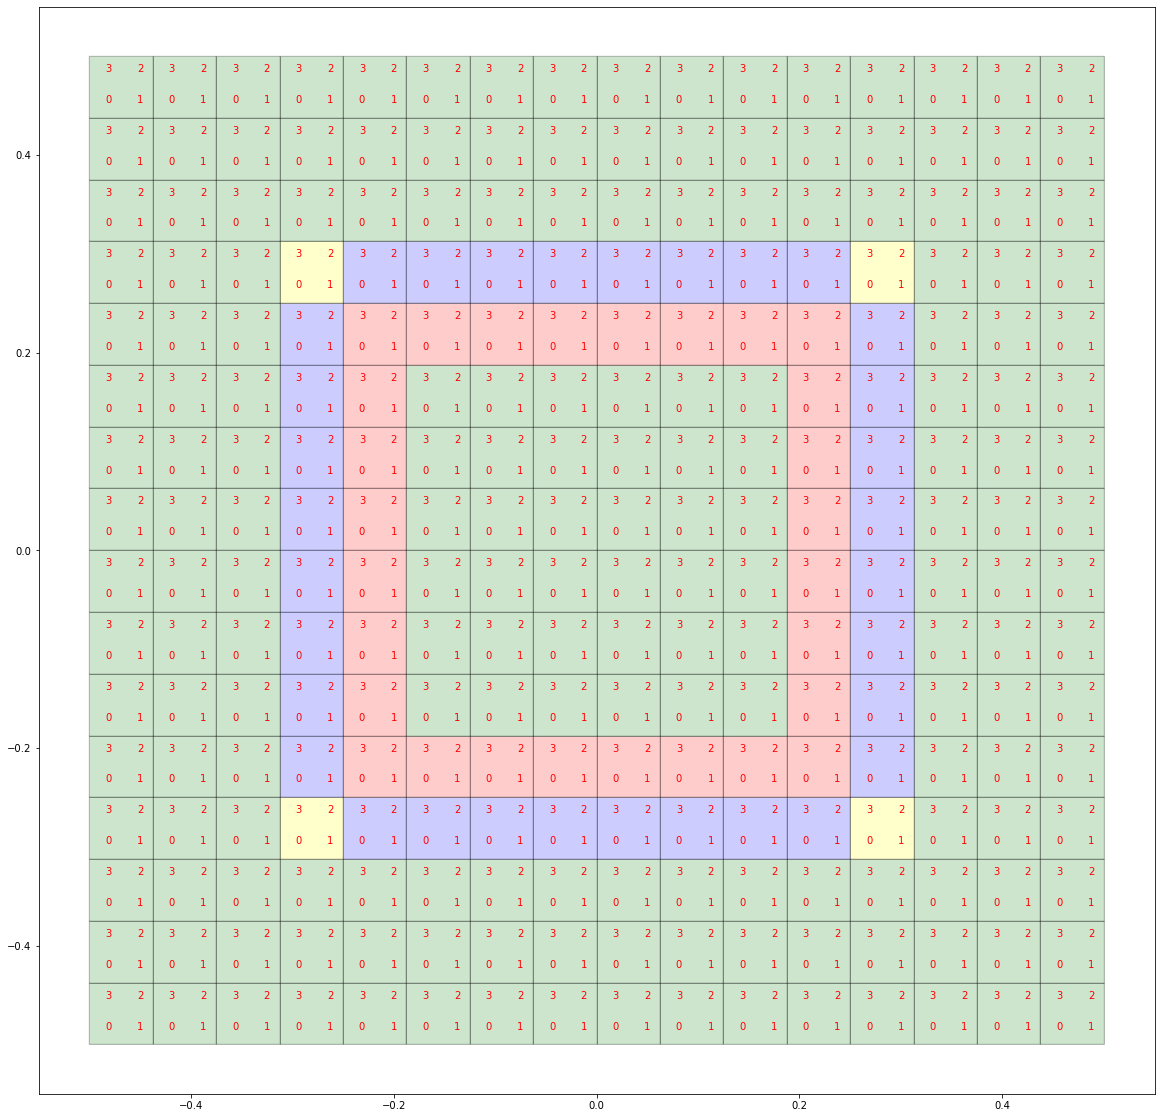

In [10]:
def visualize_quad_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    # trace underlying mesh 
    for ifa in range(mesh.Nfaces):
        nvert = 4
        verts = []
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.side_mask[ifa]==0):
                color = 'red'
            else:
                color = 'blue'
            if (mesh.cut_faces[ifa]==0):
                color = 'green'
            if (mesh.cut_faces[ifa]==3):
                color = 'yellow'
            for ino in range(nvert):
                p1 = mesh.coords[mesh.faces[ifa,ino],:]
                p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
                verts.append(p1[0:2])
                dx = p2-p1
                xx = [p1[0],p2[0]]
                yy = [p1[1],p2[1]]
                ax.plot(xx,yy,'k', linewidth=0.1)
                bary = ddr.barycenter(mesh,ifa)
                text_pos = bary+0.5*(p1-bary)
                text= str(ino)
                ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='red')
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=color, alpha=0.2)
            ax.add_patch(element)
            
visualize_quad_mesh(mesh)

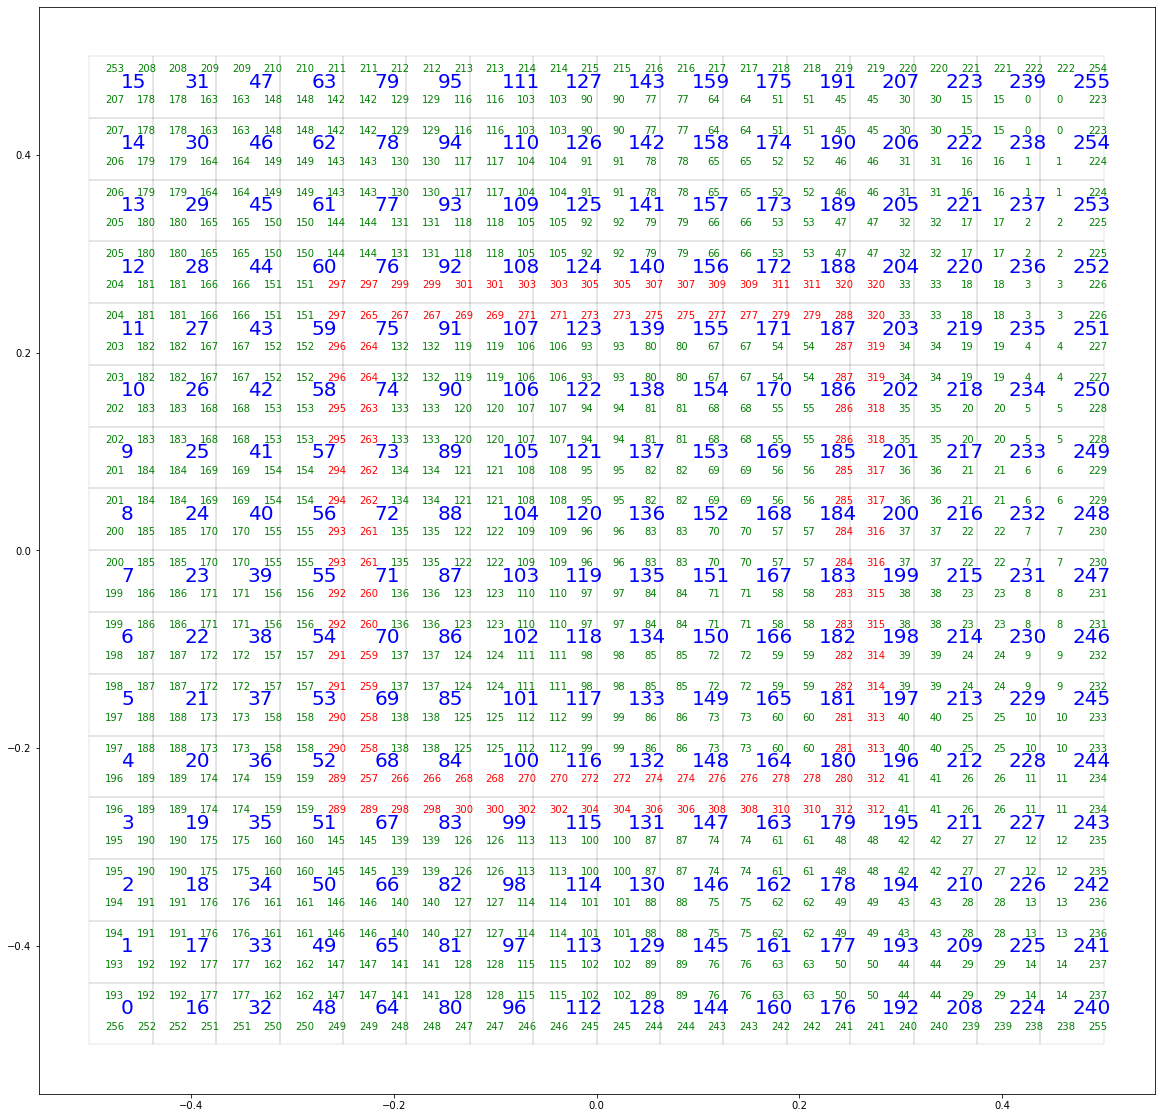

In [11]:
# visualize global index

def visualize_mesh(mesh):
    fig, ax = plt.subplots(figsize=(20,20))
    for ifa in range(mesh.Nfaces):
        nvert = 4
        for ino in range(nvert):
            # draw edges
            p1 = mesh.coords[mesh.faces[ifa,ino],:]
            p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
            dx = p2-p1
            xx = [p1[0],p2[0]]
            yy = [p1[1],p2[1]]
            ax.plot(xx,yy,'k', linewidth=0.1)
            bary = ddr.barycenter(mesh,ifa)
            text_pos = bary+0.5*(p1-bary)
            text= str(ddr.glob_idx(mesh,ifa,ino))
            #text = str(mesh.faces[ifa,ino])
            #if (ddr.glob_idx(mesh,ifa,ino)>(mesh.Ndof-2*(mesh.Npoints-mesh.Npoints_init))):
            #if (is_on_intface(mesh, mesh.faces[ifa,ino])):
            if (mesh.faces[ifa,ino]>=mesh.Npoints_init):
                color = "red"
            else:
                color = "green"
            ax.text(text_pos[0], text_pos[1], text, fontsize=10, color=color)
        # write face number
        text_pos = ddr.barycenter(mesh,ifa)
        text= str(ifa)
        ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='blue')

visualize_mesh(mesh)

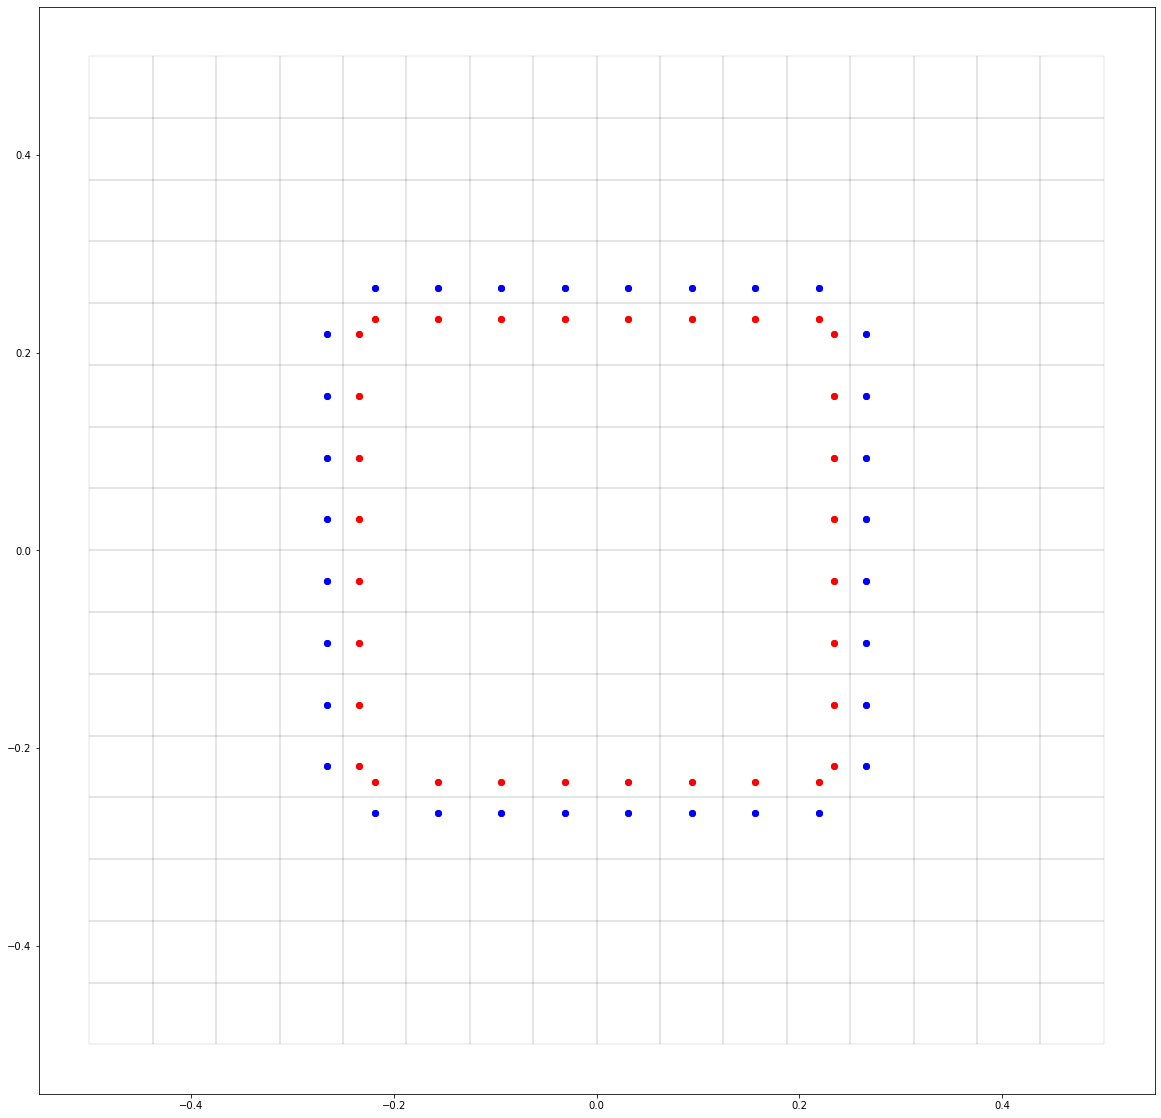

In [12]:
# check edge_on_intface

def check_edge_on_intface(mesh, edge_on_intface):
    fig, ax = plt.subplots(figsize=(20,20))
    for ied in range(len(mesh.gamma_edges)):
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        nvert = 4
        # spot in 
        edge_in = edge_on_intface[ied][0]
        midpoint_in = 0.5*(mesh.coords[mesh.faces[ifa_in, edge_in]] + \
                        mesh.coords[mesh.faces[ifa_in, (edge_in+1)%nvert]])
        bary_in = ddr.barycenter(mesh, ifa_in)
        pos = 0.5*(bary_in+midpoint_in)
        ax.scatter([pos[0], pos[0]], [pos[1], pos[1]], color="red")
        # spot ex
        edge_ex = edge_on_intface[ied][1]
        midpoint_ex = 0.5*(mesh.coords[mesh.faces[ifa_ex, edge_ex]] + \
                        mesh.coords[mesh.faces[ifa_ex, (edge_ex+1)%nvert]])
        bary_ex = ddr.barycenter(mesh, ifa_ex)
        pos = 0.5*(bary_ex+midpoint_ex)
        ax.scatter([pos[0], pos[0]], [pos[1], pos[1]], color="blue")
    for ifa in range(mesh.Nfaces):
        for ino in range(nvert):
            # draw edges
            p1 = mesh.coords[mesh.faces[ifa,ino],:]
            p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
            dx = p2-p1
            xx = [p1[0],p2[0]]
            yy = [p1[1],p2[1]]
            ax.plot(xx,yy,'k', linewidth=0.1)

check_edge_on_intface(mesh, edge_on_intface)

Pretty Sure that ```edge_on_intface``` is OK

## PROBLEM DATA 

In [15]:
# data 
L = 0.5 # semi-side
l = 0.25 # semi-side internal square
sigma_in = 0.1
sigma_ex = 1
phi_datum = lambda x,y: -9*x
    

# ref sol: expressions in x,y 
ref_sol_in = lambda x,y: 10*x
ref_sol_ex = lambda x,y: x

def reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex):
    ### get coordinates of point
    if (dof<mesh.Npoints):
        point = mesh.coords[dof,:]
    else:
        shift = mesh.Npoints-mesh.Npoints_init
        point = mesh.coords[dof-shift,:]
    x = point[0]
    y = point[1]
    ### get side and return
    if (dof<mesh.Npoints_init):
        if (np.abs(point[0])<l and np.abs(point[1])<l):
            return ref_sol_in(x,y)
        else:
            return ref_sol_ex(x,y)
    elif (dof<mesh.Npoints):
        return ref_sol_in(x,y)
    else:
        return ref_sol_ex(x,y)

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_in=ref_sol_in, ref_sol_ex=ref_sol_ex: \
          reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex) 



#### MESH ASSEMBLING ADAPTED: 
interface edge is not always first, so I have to use the edge_element2edge_face connectivity

nodes on face in:  4
nodes on face ex:  4


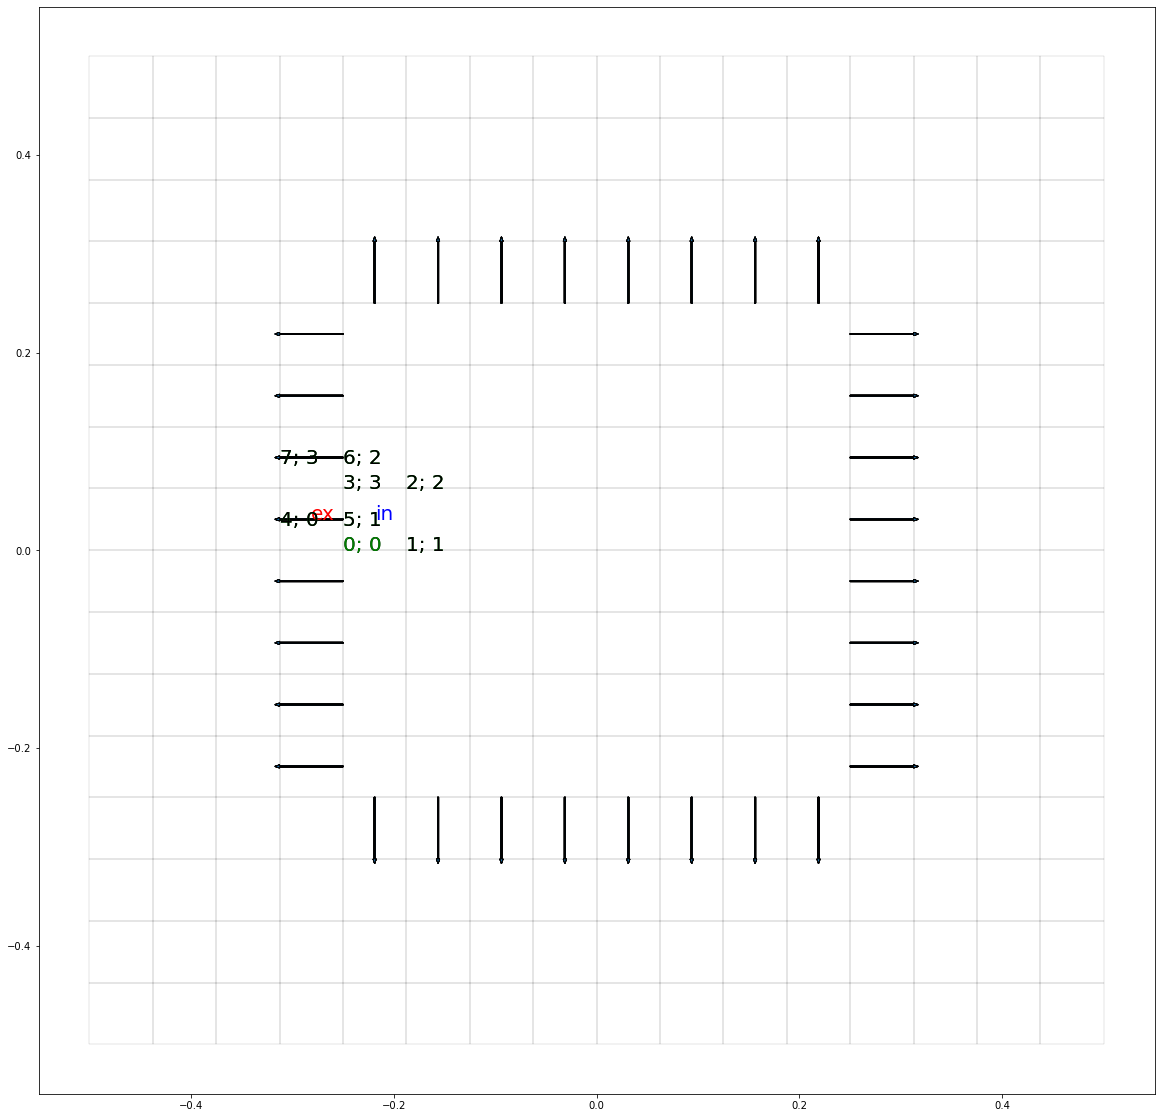

In [16]:
def assemble_M_gamma_quad(mesh, sigma_in, sigma_ex, edge_on_intface, visualize):
    if (visualize): 
        fig, ax = plt.subplots(figsize=(20,20))
    to_check = 5
    # visualize underlying mesh
    #################################################################
    if (visualize):
        for ifa in range(mesh.Nfaces):
            if (mesh.cut_faces[ifa]!=1):
                nvert = 4
                for ino in range(nvert):
                    p1 = mesh.coords[mesh.faces[ifa,ino],:]
                    glob_ino = mesh.faces[ifa,(ino+1)%nvert]
                    p2 = mesh.coords[glob_ino,:]
                    dx = p2-p1
                    xx = [p1[0],p2[0]]
                    yy = [p1[1],p2[1]]
                    ax.plot(xx,yy,'k', linewidth=0.1)
    ##################################################################
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    for ied in range(len(mesh.gamma_edges)):
        # table of dofs touched by the edge
        # 8 dofs: 4 in + 4 ex
        edge_dofs = np.zeros((8,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        # show detailed info for specific example
        ##############################################################
        if (visualize and ied==to_check):
            print ("nodes on face in: ", node_per_face_in)
            print ("nodes on face ex: ", node_per_face_ex)
            pos_ifa_in = ddr.barycenter(mesh,ifa_in)
            pos_ifa_ex = ddr.barycenter(mesh,ifa_ex)
            ax.text(pos_ifa_in[0], pos_ifa_in[1], "in", fontsize=20, color='blue')
            ax.text(pos_ifa_ex[0], pos_ifa_ex[1], "ex", fontsize=20, color='red')
        ##############################################################
        
        ## list of dofs implicated 
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in, 0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in, 1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex, 0] = ddr.glob_idx(mesh, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex, 1] = ifa_ex
        
        # loop on phi_i
        for idof1 in range(8):
            dof1 = edge_dofs[idof1, 0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1, 1] #idx of face$
            
            # Show dofs
            ########################################################################
            if (visualize and ied==to_check):
                if (dof1<mesh.Npoints):
                    ino = dof1
                else:
                    ino = dof1 - (mesh.Npoints-mesh.Npoints_init)
                text_pos = mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa1==ifa_ex)
                text = str(idof1)+"; "+str(dof1_loc)
                ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='black')
            ########################################################################
            
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            # get edge on interface for face in (its 2 points) 
            ino_edge1 = edge_on_intface[ied][0]
            ino_edge2 = (ino_edge1+1)%node_per_face_in
            #counter-clockwise
            tangent = mesh.coords[mesh.faces[ifa_in,ino_edge2],0:2]- \
                      mesh.coords[mesh.faces[ifa_in,ino_edge1],0:2]
            normal  = np.array([[0,1],[-1,0]])@tangent
            # add it to plot
            midpoint = 0.5*(mesh.coords[mesh.faces[ifa_in,ino_edge2],0:2]+ \
                            mesh.coords[mesh.faces[ifa_in,ino_edge1],0:2])
            if (visualize):
                ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc],normal)
            
            # loop on phi_j
            for idof2 in range(8):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1]
                R2 = ddr.recpot(mesh,ifa2)
                # Show dofs ###########################################################
                if (visualize and ied==to_check and idof1==0):
                    if (dof2<mesh.Npoints):
                        ino = dof2
                    else:
                        ino = dof2 - (mesh.Npoints-mesh.Npoints_init)
                    text_pos= mesh.coords[ino,0:2]+np.array([0,0.025])*(ifa2==ifa_ex)
                    text = str(idof2)+"; "+str(dof2_loc)
                    ax.text(text_pos[0], text_pos[1], text, fontsize=20, color='green')
                #######################################################################
                ## Setting which of 2 nodes on interface comes first, 
                ## should be indifferent though
                node_per_face_2 = np.count_nonzero(mesh.faces[ifa2,:] != -1)
                if (ifa2==ifa_in):
                    intf_edge = edge_on_intface[ied][0]
                else:
                    intf_edge = edge_on_intface[ied][1]
                ino_edge1 = intf_edge
                ino_edge2 = (intf_edge+1)%node_per_face_2
                if (ifa2 == ifa_in):
                    v2A = R2[ino_edge1,dof2_loc]
                    v2B = R2[ino_edge2,dof2_loc]
                else:
                    v2A = R2[ino_edge2,dof2_loc]
                    v2B = R2[ino_edge1,dof2_loc]
                # sign (jump must be ex-in)
                sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                ## integral
                jump_of_rec = 0.5*(v2A+v2B)*sign2
                M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*jump_of_rec
        
    return M_gamma 

M_gamma = assemble_M_gamma_quad(mesh,sigma_in,sigma_ex, edge_on_intface, visualize = True)

#### Versione che ha aggiustato l'unstructrued 1D

In [17]:
def assemble_M_gamma_quad(mesh,sigma_in,sigma_ex, edge_on_intface, visualize):
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((mesh.Ndof,mesh.Ndof))
    
    for ied in range(len(mesh.gamma_edges)):
        # table of dofs touched by the edge
        # 8 dofs: 4 + 4
        edge_dofs = np.zeros((8,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
        for idof1 in range(8):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face$
            GR1 = ddr.GR(mesh,ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            # get edge on interface for face in (its 2 points) 
            ino_edge1 = edge_on_intface[ied][0]
            ino_edge2 = (ino_edge1+1)%node_per_face_in
            #counter-clockwise
            tangent = mesh.coords[mesh.faces[ifa_in,ino_edge2],0:2]- \
                      mesh.coords[mesh.faces[ifa_in,ino_edge1],0:2]
            normal  = np.array([[0,1],[-1,0]])@tangent
            
            mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc],normal)
            ## Setting which of 2 nodes on interface comes first, 
            ## should be indifferent though
            intf_edge_in = edge_on_intface[ied][0]
            intf_edge_ex = edge_on_intface[ied][1]
            ino_edge1_in = intf_edge_in
            ino_edge2_in = (intf_edge_in+1)%4
            ino_edge1_ex = intf_edge_ex
            ino_edge2_ex = (intf_edge_ex+1)%4
            
            dof_intf_in_1 = ddr.glob_idx(mesh, ifa_in, ino_edge1_in)
            dof_intf_in_2 = ddr.glob_idx(mesh, ifa_in, ino_edge2_in)
            dof_intf_ex_1 = ddr.glob_idx(mesh, ifa_ex, ino_edge1_ex)
            dof_intf_ex_2 = ddr.glob_idx(mesh, ifa_ex, ino_edge2_ex)
 
            M_gamma[dof1,dof_intf_in_1] = M_gamma[dof1,dof_intf_in_1] - mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_in_2] = M_gamma[dof1,dof_intf_in_2] - mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_ex_1] = M_gamma[dof1,dof_intf_ex_1] + mean_sigma_grad_normal*0.5
            M_gamma[dof1,dof_intf_ex_2] = M_gamma[dof1,dof_intf_ex_2] + mean_sigma_grad_normal*0.5
            
    return M_gamma         

mesh = Meshes[0]
M_gamma = assemble_M_gamma_quad(mesh, sigma_in ,sigma_ex, edge_on_intface, visualize = False)

NameError: name 'Meshes' is not defined

#### Continuity at Interface ($\eta$):
- $N_\Gamma$
- $b_{\Phi}$

In [18]:
def assemble_N_gamma_quad(mesh, edge_on_intface):
    # matrix N_gamma (jump penalisation)
    N_gamma = np.zeros((mesh.Ndof, mesh.Ndof))
    for ied in range(len(mesh.gamma_edges)):
        # table of dofs touched by the edge
        # 7 dofs: 4 in + 4 ex
        edge_dofs = np.zeros((8,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        ### get dofs and corresponding faces interested by the edge
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh,ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        ### loop for phi_i
        for idof1 in range(8):
            # get nodal values of reconstruction
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1]
            R1 = ddr.recpot(mesh,ifa1)
            ## by construction the two nodes of the interface edge 
            ## are swapped in the local ordering of the 2 elements
            node_per_face_1 = np.count_nonzero(mesh.faces[ifa1,:] != -1)
            if (ifa1 == ifa_in):
                intf_edge = edge_on_intface[ied][0]
                ino_edge1 = intf_edge
                ino_edge2 = (intf_edge+1)%node_per_face_in
                v1A = R1[ino_edge1,dof1_loc]
                v1B = R1[ino_edge2,dof1_loc]
            else:
                intf_edge = edge_on_intface[ied][1]
                ino_edge1 = intf_edge
                ino_edge2 = (intf_edge+1)%node_per_face_ex
                v1A = R1[ino_edge2,dof1_loc]
                v1B = R1[ino_edge1,dof1_loc]
            # sign (jump must be ex-in)
            sign1 = int(ifa1==ifa_ex)-int(ifa1==ifa_in)
            ### loop for phi_j
            for idof2 in range(8):
                dof2 = edge_dofs[idof2,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1]
                R2 = ddr.recpot(mesh,ifa2)
                # ATTENTION: mind the order of interface edge nodes according to side
                node_per_face_2 = np.count_nonzero(mesh.faces[ifa2,:] != -1)
                if (ifa2 == ifa_in):
                    intf_edge = edge_on_intface[ied][0]
                    ino_edge1 = intf_edge
                    ino_edge2 = (intf_edge+1)%node_per_face_in
                    v2A = R2[ino_edge1,dof2_loc]
                    v2B = R2[ino_edge2,dof2_loc]
                else:
                    intf_edge = edge_on_intface[ied][1]
                    ino_edge1 = intf_edge
                    ino_edge2 = (intf_edge+1)%node_per_face_ex
                    v2A = R2[ino_edge2,dof2_loc]
                    v2B = R2[ino_edge1,dof2_loc]
                # sign (jump must be ex-in)
                sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                # contribution
                ## edge length (it's the same for every edge, so don't correct)
                mod_E = np.linalg.norm(mesh.coords[mesh.faces[ifa2,0],:]-mesh.coords[mesh.faces[ifa2,1],:])
                ## integral
                local_contrib = ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
                N_gamma[dof1,dof2] = N_gamma[dof1,dof2] + mod_E*sign1*sign2*local_contrib
    return N_gamma

N_gamma = assemble_N_gamma_quad(mesh, edge_on_intface)

In [19]:
def assemble_b_phi_quad(mesh, phi_datum, edge_on_intface):
    b_phi = np.zeros((mesh.Ndof))
    for ied in range(len(mesh.gamma_edges)):
        # table of dofs touched by the edge
        # 8 dofs: 4 in + 4 ex
        edge_dofs = np.zeros((8,2),dtype=int)
        ifa_in = mesh.gamma_edges[ied][0]
        ifa_ex = mesh.gamma_edges[ied][1]
        node_per_face_in = np.count_nonzero(mesh.faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(mesh.faces[ifa_ex,:] != -1)
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = ddr.glob_idx(mesh, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = ddr.glob_idx(mesh,ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
        for idof in range(8):
            # get nodal values of reconstruction
            dof = edge_dofs[idof,0] #global idx
            if (idof<node_per_face_in): #local idx
                dof_loc = idof
            else:
                dof_loc = idof-node_per_face_in
            ifa = edge_dofs[idof,1]
            R = ddr.recpot(mesh,ifa)
            ## choose right interface nodes using edge_on_intface
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            if (ifa == ifa_in):
                intf_edge = edge_on_intface[ied][0]
                ino_edge1 = intf_edge
                ino_edge2 = (intf_edge+1)%node_per_face_in
                v1A = R[ino_edge1,dof_loc]
                v1B = R[ino_edge2,dof_loc]
                # need to find the global idx
                ino_edge1_glob = mesh.faces[ifa, ino_edge1]
                ino_edge2_glob = mesh.faces[ifa, ino_edge2]
                xA = mesh.coords[ino_edge1_glob,0]
                yA = mesh.coords[ino_edge1_glob,1]
                xB = mesh.coords[ino_edge2_glob,0]
                yB = mesh.coords[ino_edge2_glob,1]
            else:
                intf_edge = edge_on_intface[ied][1]
                ino_edge1 = intf_edge
                ino_edge2 = (intf_edge+1)%node_per_face_ex
                v1A = R[ino_edge2,dof_loc]
                v1B = R[ino_edge1,dof_loc]
                ino_edge1_glob = mesh.faces[ifa, ino_edge1]
                ino_edge2_glob = mesh.faces[ifa, ino_edge2]
                xA = mesh.coords[ino_edge2_glob,0]
                yA = mesh.coords[ino_edge2_glob,1]
                xB = mesh.coords[ino_edge1_glob,0]
                yB = mesh.coords[ino_edge1_glob,1]
            v2A = phi_datum(xA,yA)
            v2B = phi_datum(xB,yB)
            #print ("values: ", v2A, v2B)
            #print (v1A, v1B)
            ## edge length (all edges are the same, so doesn't matter what I take)
            mod_E = np.linalg.norm(mesh.coords[mesh.faces[ifa,0],:]-mesh.coords[mesh.faces[ifa,1],:])
            # sign (jump must be ex-in)
            sign = int(ifa==ifa_ex)-int(ifa==ifa_in)
            # local contribution
            local_contrib = ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
            # integral
            b_phi[dof] = b_phi[dof] + mod_E*sign*local_contrib
    return b_phi

phi_datum = lambda x,y: -9*x

b_phi = assemble_b_phi_quad(mesh, phi_datum, edge_on_intface)

#### BOUNDARY TREATMENT
- boundary connectivity
- Matrix $DIR$ to impose weakly boundary condition (used for weak bnd case)
- Matrix $FLUX_{bnd}$ for external flux

Implementazione con Ricostruzione (non cambia nulla)

In [ ]:
def assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize):
    if (visualize): 
        fig, ax = plt.subplots(figsize=(20,20))
    # visualize underlying mesh
    #################################################################
    if (visualize):
        for ifa in range(mesh.Nfaces):
            if (mesh.cut_faces[ifa]!=1):
                nvert = 4
                for ino in range(nvert):
                    p1 = mesh.coords[mesh.faces[ifa,ino],:]
                    glob_ino = mesh.faces[ifa,(ino+1)%nvert]
                    p2 = mesh.coords[glob_ino,:]
                    dx = p2-p1
                    xx = [p1[0],p2[0]]
                    yy = [p1[1],p2[1]]
                    ax.plot(xx,yy,'k', linewidth=0.1)
    ##################################################################
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        bnd_locdof1 = bnd_edges[ie][1] # index of node
        bnd_locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, bnd_locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, bnd_locdof2)
        ino1 = mesh.faces[ifa, bnd_locdof1] # index of node
        ino2 = mesh.faces[ifa, bnd_locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        # fluxes of test functions
        G = ddr.GR(mesh, ifa)
        R = ddr.recpot(mesh, ifa)
        tangent = p2 - p1
        normal = np.array([[0,1],[-1,0]])@tangent[0:2]
        ###############################################################
        # visualize normal (suppressed section)
        if (visualize):
            midpoint = 0.5*(p1+p2)
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
        ###############################################################
        node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
        # loop over all dofs of elements
        for locdof1 in range(node_per_face):
            idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
            v1A = R[bnd_locdof1, locdof1]
            v1B = R[bnd_locdof2, locdof1]
            for locdof2 in range(node_per_face):
                idof2 = ddr.glob_idx(mesh, ifa, locdof2) # global dof
                flux = sigma_ex*np.dot(G[:,locdof2], normal)
                DIR[idof1,idof2] = DIR[idof1,idof2] + flux*0.5*(v1A+v1B)
    return DIR

FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize=True)

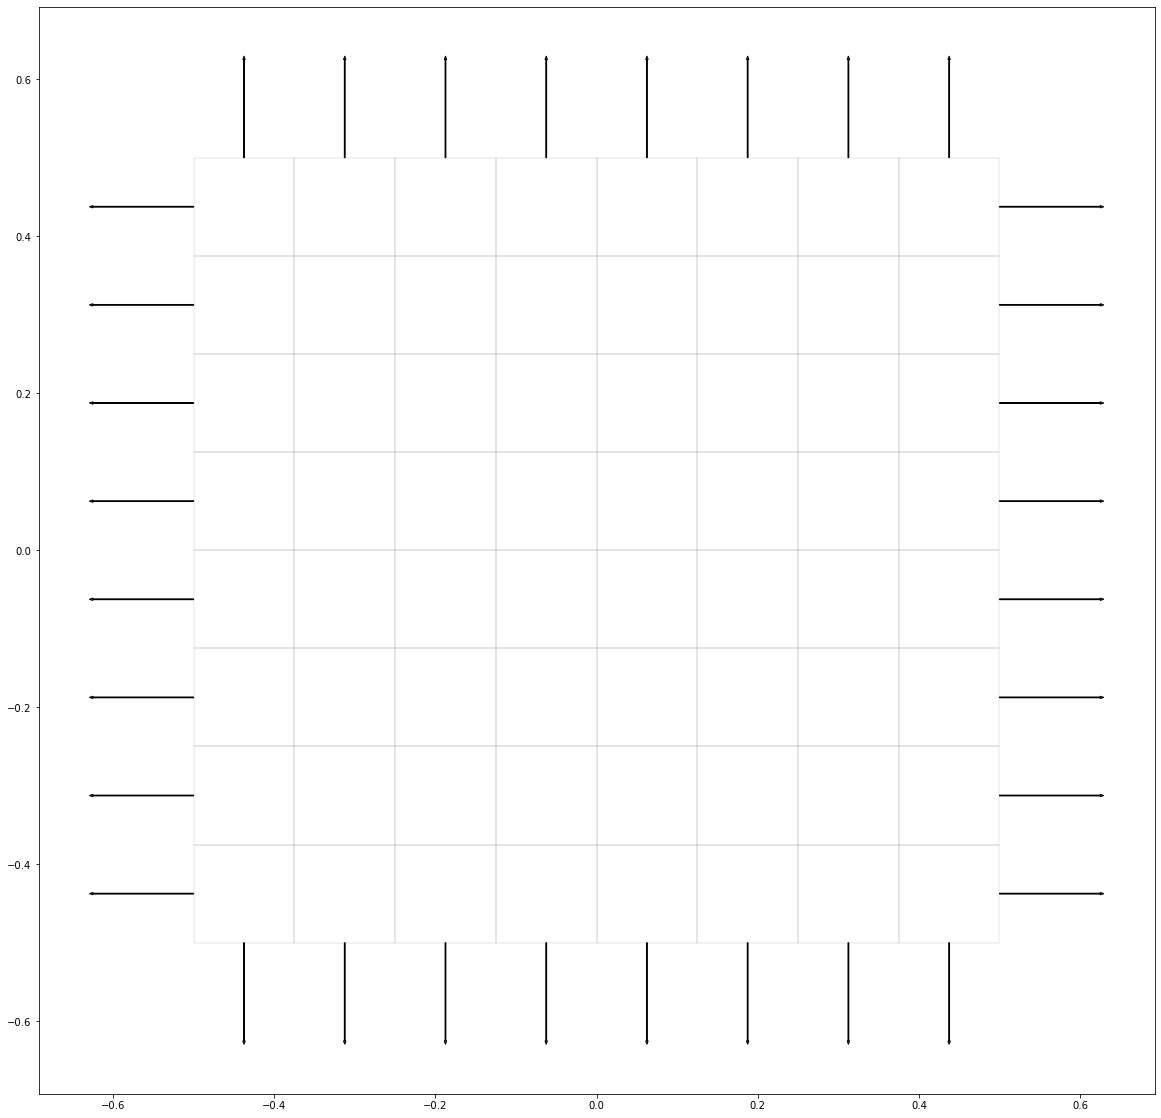

In [23]:
# function to create connectivity bnd_edge2[node1,node2]
def create_bnd_connectivity(mesh):
    bnd_edges = []
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa] != 1):
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            for ie in range(node_per_face):
                ino1 = mesh.faces[ifa,ie] # should be counter clockwise
                ino2 = mesh.faces[ifa,(ie+1)%node_per_face]
                if (mesh.bnd_mask[ino1]>0 and mesh.bnd_mask[ino2]>0):
                    edge = np.array([ifa,ie,(ie+1)%node_per_face]) # record face and 2 local dofs
                    bnd_edges.append(edge)

    return bnd_edges

def assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize):
    if (visualize): 
        fig, ax = plt.subplots(figsize=(20,20))
    # visualize underlying mesh
    #################################################################
    if (visualize):
        for ifa in range(mesh.Nfaces):
            if (mesh.cut_faces[ifa]!=1):
                nvert = 4
                for ino in range(nvert):
                    p1 = mesh.coords[mesh.faces[ifa,ino],:]
                    glob_ino = mesh.faces[ifa,(ino+1)%nvert]
                    p2 = mesh.coords[glob_ino,:]
                    dx = p2-p1
                    xx = [p1[0],p2[0]]
                    yy = [p1[1],p2[1]]
                    ax.plot(xx,yy,'k', linewidth=0.1)
    ##################################################################
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa, locdof1] # index of node
        ino2 = mesh.faces[ifa, locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        # fluxes of test functions
        G = ddr.GR(mesh, ifa)
        tangent = p2 - p1
        normal = np.array([[0,1],[-1,0]])@tangent[0:2]
        ###############################################################
        # visualize normal (suppressed section)
        if (visualize):
            midpoint = 0.5*(p1+p2)
            ax.arrow(midpoint[0],midpoint[1],normal[0],normal[1])
        ###############################################################
        node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
        # loop over all dofs of elements
        for locdof in range(node_per_face):
            idof = ddr.glob_idx(mesh, ifa, locdof) # global dof
            flux = sigma_ex*np.dot(G[:,locdof], normal)
            DIR[idof1,idof] = DIR[idof1,idof] + flux*0.5
            DIR[idof2,idof] = DIR[idof2,idof] + flux*0.5
    return DIR

FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize=True)

# function to assemble DIR matrix
def assemble_DIR(mesh, bnd_edges):
    DIR = np.zeros((mesh.Ndof,mesh.Ndof))
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # index of node
        locdof2 = bnd_edges[ie][2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        ino1 = mesh.faces[ifa,locdof1] # index of node
        ino2 = mesh.faces[ifa,locdof2]
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2] 
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        DIR[idof1,idof1] = DIR[idof1,idof1] + ddr.calc_r2_prod_integ(v1A,v1B,v1A,v1B) # notice, it's symmetric
        DIR[idof1,idof2] = DIR[idof1,idof2] + ddr.calc_r2_prod_integ(v1A,v1B,v2A,v2B)
        DIR[idof2,idof1] = DIR[idof2,idof1] + ddr.calc_r2_prod_integ(v2A,v2B,v1A,v1B)
        DIR[idof2,idof2] = DIR[idof2,idof2] + ddr.calc_r2_prod_integ(v2A,v2B,v2A,v2B)
    return DIR

# function to assemble b_g vector
def assemble_b_dir(mesh, bnd_edges, ref_sol):
    b_dir = np.zeros(mesh.Ndof)
    for ie in range(len(bnd_edges)):
        ifa  = bnd_edges[ie][0]
        locdof1 = bnd_edges[ie][1] # local dof
        locdof2 = bnd_edges[ie][2]
        ino1  = mesh.faces[ifa,locdof1] # index of node
        ino2  = mesh.faces[ifa,locdof2]
        idof1 = ddr.glob_idx(mesh, ifa, locdof1) # global dof
        idof2 = ddr.glob_idx(mesh, ifa, locdof2)
        p1 = mesh.coords[ino1] # point coord
        p2 = mesh.coords[ino2]
        v1A = 1
        v1B = 0
        v2A = 0
        v2B = 1 # maybe overkill to use calc_r2_prod_integ
        gA = ref_sol(mesh, idof1)
        gB = ref_sol(mesh, idof2)
        b_dir[idof1] = b_dir[idof1] + ddr.calc_r2_prod_integ(v1A,v1B,gA,gB)
        b_dir[idof2] = b_dir[idof2] + ddr.calc_r2_prod_integ(v2A,v2B,gA,gB)
    return b_dir

### Visualize Exact Solution

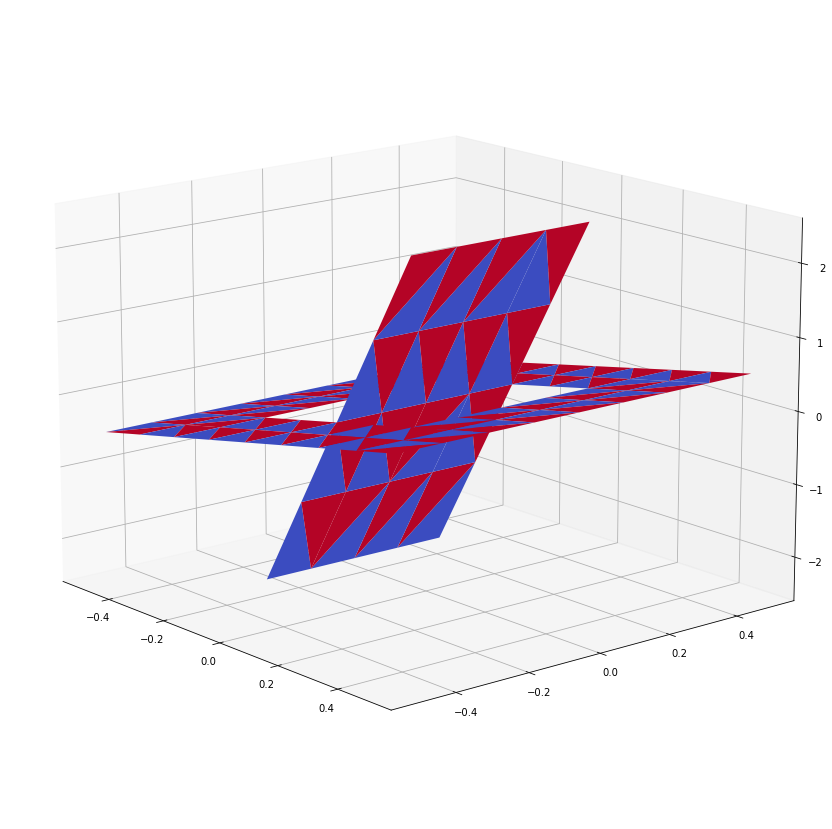

In [24]:
#VISUALIZATION OF ERROR
mesh_filename ="square_quads_L1_N8.msh"
mesh = load_quad_mesh(mesh_filename) 
edge_on_intface = complete_mesh_info(mesh, N)
refactor_mesh(mesh, N)
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]       

ddr.plot_solution(mesh, u_ref, elevation=15, azimuth=-40)

### System Solution (Strong Enforcement of Boundary Conditions)

In [ ]:
# Solve problem for each mesh in the sequence and record error 
size_list = [64]
mesh_filenames = ["square_quads_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
FLUX_bnd_matrices = []
DIR_matrices = []
b_dir_vectors = []
N_gamma_matrices = []
b_phi_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_quads_L1_N"+str(size)+".vtk" for size in size_list]

eta = 1
tolerance = 1e-20 # imposed tolerance for linear solver

for (i,N) in enumerate (size_list):
    
    # mesh preparation : MODIFIED to adapt to quads 
    mesh = load_quad_mesh(mesh_filenames[i]) 
    edge_on_intface = complete_mesh_info(mesh, N)
    refactor_mesh(mesh, N)
    set_side_mask(mesh, l)
    # mark boundaries
    ddr.mark_bnd_points(mesh)
    bnd_edges = create_bnd_connectivity(mesh)
    # assemble system
    G = ddr.assemble_G(mesh, sigma_in,sigma_ex) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    # MODIFIED (interface edge now is not on first face)
    M_gamma = assemble_M_gamma_quad(mesh,sigma_in, sigma_ex, edge_on_intface, visualize = False)
    FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize = False)
    N_gamma = assemble_N_gamma_quad(mesh, edge_on_intface)
    b_phi = assemble_b_phi_quad(mesh, phi_datum, edge_on_intface)
    DIR = assemble_DIR(mesh, bnd_edges)
    b_dir = assemble_b_dir (mesh, bnd_edges, ref_sol)
    # define system, apply bc conds an solve
    A =  G+S+eta*N_gamma +np.transpose(M_gamma) # M with - because normal vec from in to ex
                                                # check this, because apparently it's better with +
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    # impose also bnd conds to each of matrices
    [N_gamma, b_gamma] = ddr.impose_bc(mesh, N_gamma, b_phi, ref_sol)
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "G+M_Gamma-FLUX_bnd ", np.max( np.abs( np.dot( G+np.transpose(M_gamma)-FLUX_bnd, u ) ) ), \
                          "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma ", np.max(np.abs(np.dot(N_gamma,u)-b_gamma)), \
                          "DIR", np.max(np.abs(np.dot(DIR,u)-b_dir)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)))
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    FLUX_bnd_matrices.append(FLUX_bnd)
    N_gamma_matrices.append(N_gamma)
    DIR_matrices.append(DIR)
    b_dir_vectors.append(b_dir)
    b_phi_vectors.append(b_phi)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

#### Osservazioni:

- occorre "+" np.transpose(M_Gamma): perchè?

###### Show Solution

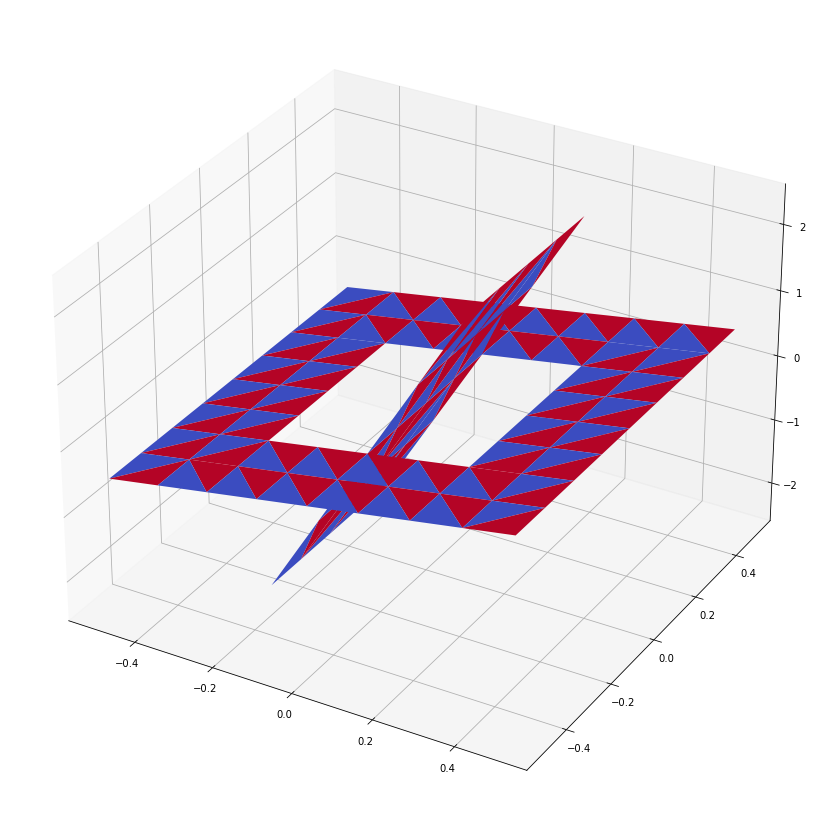

Error:  5.644887566443019e-13
Error:  1.7674750552032492e-13


In [26]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=30, azimuth=-60)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))
print ("Error: ", ddr.calc_L0_error(Meshes[n],solutions[n],ref_sol))

### VISUALIZZAZIONE D'IMPATTO

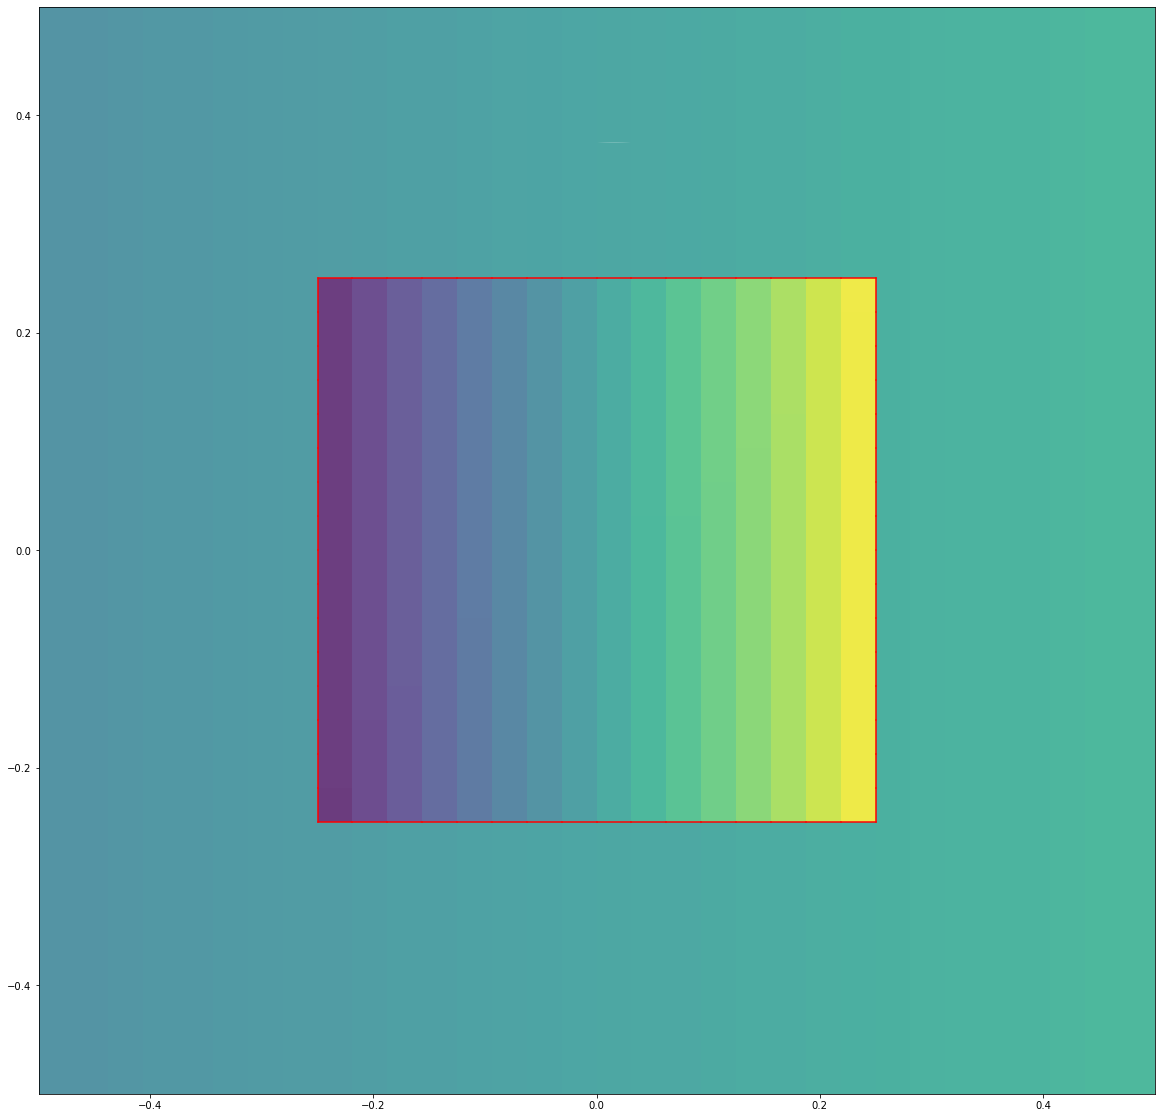

In [43]:
colmap = plt.get_cmap('viridis')
max_u = np.max(u)
min_u = np.min(u)

# function to visualize
def pretty_visualize(mesh, u):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
 
    for ifa in range(mesh.Nfaces): 
        if (mesh.cut_faces[ifa]!=1):
            verts = []
            nodal_values = []
            node_per_face = np.count_nonzero(mesh.faces[ifa,:] != -1)
            
            # draw polygon
            for ino in range(node_per_face):
                point = mesh.coords[mesh.faces[ifa,ino],:]
                dof = ddr.glob_idx(mesh, ifa, ino)
                verts.append(point[0:2])
                nodal_values.append(u[dof]) 
            color = colmap((np.mean(nodal_values)-min_u)/(max_u-min_u))
            element = Polygon(verts, closed=True,\
                              facecolor=color, alpha=0.8)
            ax.add_patch(element)
        
    for ied in range(len(mesh.gamma_edges)):
        ifa_in = mesh.gamma_edges[ied][0]
        nvert = 4
        edge_in = edge_on_intface[ied][0]
        p1 = mesh.coords[mesh.faces[ifa_in, edge_in]]
        p2 = mesh.coords[mesh.faces[ifa_in, (edge_in+1)%nvert]]
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="red")

            

pretty_visualize (mesh, u)

#### Check Residuals of system on exact solution

In [ ]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
b = b_vectors[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\n(M_gamma ", np.max(np.abs(np.dot(M_gamma,u_ref))),")" \
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\nG+M_Gamma-FLUX_bnd", np.max(np.abs( np.dot(G+np.transpose(M_gamma)-FLUX_bnd, u_ref) )), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))

Check on $M_\Gamma$. I can predict value (un po' inutile)

In [ ]:
# CHECK M_gamma with exact solution
n = 0
mesh = Meshes[n]
u = solutions[n]
M_gamma = M_gamma_matrices[n]       

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(np.transpose(M_gamma),u_ref), elevation=30, azimuth=-60)

mean = 0.5*(0.1*1+10*0.1) 
E = 0.5*(1/size_list[n])

print ("max: ", np.max(np.dot(np.transpose(M_gamma),u)),\
       "min: ", np.min(np.dot(np.transpose(M_gamma),u)),\
       "ref: ", E*mean )

Visualizzazione Residuo $N_\Gamma$ 

In [ ]:
# CHECK system with no N_gamma exact solution
n = 0
mesh = Meshes[n]
u = solutions[n]
N_gamma = N_gamma_matrices[n] 
b_phi = b_phi_vectors[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh, np.dot(A-eta*N_gamma,u_ref)-(b-eta*b_phi), elevation=30, azimuth=-60)

Visualizzazione residuo globale 

In [ ]:
# CHECK total system with exact solution
n = 0
mesh = Meshes[n]
A = A_matrices[n]
b = b_vectors[n]       

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

ddr.plot_solution(mesh,np.dot(A,u_ref)-b, elevation=15, azimuth=-60)

Visualize Residual

Visualizza residuo $G+M_\gamma - FLUX_{\partial\Omega}$

In [ ]:
n = 0
G = G_matrices[n]
S = S_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

A = G+np.transpose(M_gamma)-FLUX_bnd

ddr.plot_solution(Meshes[n], np.dot(A,u_ref), elevation=20, azimuth=80)

## Weak Treatment of Dirichlet Boundary Conditions (P1 solution)

In [ ]:
# data 
L = 0.5 # semi-side
l = 0.25 # semi-side internal square
sigma_in = 0.1
sigma_ex = 1
phi_datum = lambda x,y: -9*x
    

# ref sol: expressions in x,y 
ref_sol_in = lambda x,y: 10*x
ref_sol_ex = lambda x,y: x

def reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex):
    ### get coordinates of point
    if (dof<mesh.Npoints):
        point = mesh.coords[dof,:]
    else:
        shift = mesh.Npoints-mesh.Npoints_init
        point = mesh.coords[dof-shift,:]
    x = point[0]
    y = point[1]
    ### get side and return
    if (dof<mesh.Npoints_init):
        if (np.abs(point[0])<l and np.abs(point[1])<l):
            return ref_sol_in(x,y)
        else:
            return ref_sol_ex(x,y)
    elif (dof<mesh.Npoints):
        return ref_sol_in(x,y)
    else:
        return ref_sol_ex(x,y)

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_in=ref_sol_in, ref_sol_ex=ref_sol_ex: \
          reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex) 


Visualization of exact solution

In [ ]:
mesh_filename ="square_quads_L1_N8.msh"
mesh = load_quad_mesh(mesh_filename) 
edge_on_intface = complete_mesh_info(mesh, N)
refactor_mesh(mesh, N)
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]       

ddr.plot_solution(mesh, u_ref, elevation=10, azimuth=-90)

you are not assuming that the test functions are vanishing at the border, so you have to add the term: $\int_{\partial\Omega} \sigma \nabla u \cdot \hat{n} v$

Visualize assembling of FLUX_bnd for debugging

In [ ]:
# Solve problem for each mesh in the sequence and record error 
size_list = [8]
mesh_filenames = ["square_quads_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
FLUX_bnd_matrices = []
DIR_matrices = []
b_phi_vectors = []
b_dir_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_quads_L1_N"+str(size)+".vtk" for size in size_list]

eta = 1
mu  = 1
tolerance = 1e-20 # imposed tolerance for linear solver

for (i,N) in enumerate (size_list):
    
    # mesh preparation : MODIFIED to adapt to quads 
    mesh = load_quad_mesh(mesh_filenames[i]) 
    edge_on_intface = complete_mesh_info(mesh, N)
    refactor_mesh(mesh, N)
    set_side_mask(mesh, l)
    # create boundary connectivity
    ddr.mark_bnd_points(mesh) # OK
    bnd_edges = create_bnd_connectivity(mesh)
    # assemble system
    G = ddr.assemble_G(mesh, sigma_in,sigma_ex) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    # MODIFIED (interface edge now is not on first face)
    M_gamma = assemble_M_gamma_quad(mesh,sigma_in, sigma_ex, edge_on_intface, visualize = False)
    N_gamma = assemble_N_gamma_quad(mesh, edge_on_intface)
    b_phi = assemble_b_phi_quad(mesh, phi_datum, edge_on_intface)
    FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize = False) #graphical version
    DIR = assemble_DIR(mesh, bnd_edges)
    b_dir = assemble_b_dir(mesh, bnd_edges, ref_sol)
    # define system containing weak bnd conds and solve
    A = G+S+eta*N_gamma+np.transpose(M_gamma)-FLUX_bnd+mu*DIR 
    b = eta*b_phi + mu*b_dir
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "G+M_Gamma-FLUX_bnd ", np.max( np.abs( np.dot( G+np.transpose(M_gamma)-FLUX_bnd, u ) ) ), \
                          "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma", np.max(np.abs(np.dot(N_gamma,u)-b_phi)), \
                          "DIR", np.max(np.abs(np.dot(DIR,u)-b_dir)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)) )
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    FLUX_bnd_matrices.append(FLUX_bnd)
    DIR_matrices.append(DIR)
    b_phi_vectors.append(b_phi)
    b_dir_vectors.append(b_dir)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

Visualize Solution

In [ ]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n], elevation=1, azimuth=-90)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))
print ("Error: ", ddr.calc_L0_error(Meshes[n],solutions[n],ref_sol))

In [ ]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
FLUX_bnd = FLUX_bnd_matrices[n]
b_dir = b_dir_vectors[n]
b = b_vectors[n]

A_alt = G+S+np.transpose(M_gamma)-FLUX_bnd+N_gamma+DIR # as if with eta=1 and mu=1
b_alt = b_phi + b_dir

u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\nDIR", np.max(np.abs(np.dot(DIR,u_ref)-b_dir)), \
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\ntotal_bis ", np.max(np.abs(np.dot(A_alt,u_ref)-b_alt)), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))

Visualize Error

In [ ]:
n = 0
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
ddr.plot_solution(Meshes[n], solutions[n]-u_ref, elevation=20, azimuth=0)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))
print ("Error: ", ddr.calc_L0_error(Meshes[n],solutions[n],ref_sol))

Visualize Total Residual at exact Solution

In [ ]:
n = 0
A = A_matrices[n]
b = b_vectors[n]
ddr.plot_solution(Meshes[n], np.dot(A,u_ref)-b, elevation=20, azimuth=90)

Visualize Residual of "first block" of the system: $G+M_\Gamma-FLUX_{\partial\Omega}$ 

In [ ]:
n = 0
G = G_matrices[n]
S = S_matrices[n]
M_gamma = M_gamma_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]

A = G+np.transpose(M_gamma)-FLUX_bnd

ddr.plot_solution(Meshes[n], np.dot(A,u_ref), elevation=20, azimuth=60)

Visualize $G+M_Gamma$

In [ ]:
n = 0
G = G_matrices[n]
S = S_matrices[n]
M_gamma = M_gamma_matrices[n]

A = G+np.transpose(M_gamma)

ddr.plot_solution(Meshes[n], np.dot(A,u_ref), elevation=20, azimuth=60)

Visualize residual only for border flux ($FLUX_{\partial\Omega}\cdot u_{ref}$)

In [ ]:
n = 0
FLUX_bnd = FLUX_bnd_matrices[n]

ddr.plot_solution(Meshes[n], np.dot(FLUX_bnd,u_ref), elevation=20, azimuth=60)

Check Gradient Reconstruction

In [ ]:
def visualize_gradient(mesh, u):
    fig, ax = plt.subplots(figsize=(20,20))
    for ifa in range(mesh.Nfaces):
        node_per_face =  np.count_nonzero(mesh.faces[ifa,:] != -1)
        nvert = node_per_face
        for ino in range(nvert):
            # draw edges
            p1 = mesh.coords[mesh.faces[ifa,ino],:]
            p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
            dx = p2-p1
            xx = [p1[0],p2[0]]
            yy = [p1[1],p2[1]]
            ax.plot(xx,yy,'k', linewidth=0.1)
        # arrow of gradient
        if (mesh.side_mask[ifa]==1):
            bary = ddr.barycenter(mesh, ifa)
            G = ddr.GR(mesh, ifa)
            u_F = np.zeros(node_per_face)
            for ino in range(node_per_face):
                dof = ddr.glob_idx(mesh, ifa, ino)
                u_F[ino] = u[dof]
            grad = np.dot(G, u_F)/20 #-----------------> this to show gradient of u_ref
            # grad = G[:, 3]/50          #-----------------> this to show gradient of test functions 
            ax.arrow(bary[0], bary[1], grad[0], grad[1])

visualize_gradient(mesh, u_ref)

Check Boundary Mask

In [ ]:
# CHECK BOUNDARY MASK

def visualize_bnd_points_with_dof(mesh, bnd_edges):
    fig, ax = plt.subplots(figsize=(5,5))
    for ifa in range(mesh.Nfaces):
        if (mesh.cut_faces[ifa]!=1):
            if (mesh.faces[ifa,3]==-1):
                nvert = 3
            else:
                nvert = 4
            for ino in range(nvert):
               p1 = mesh.coords[mesh.faces[ifa,ino],:]
               p2 = mesh.coords[mesh.faces[ifa,(ino+1)%nvert],:]
               dx = p2-p1
               xx = [p1[0],p2[0]]
               yy = [p1[1],p2[1]]
               ax.plot(xx,yy,'k', linewidth=0.1)
    # mark generated points
    for dof in range(mesh.Npoints):
        if (dof<mesh.Npoints):
            ino = dof
        else:
            ino = dof-(mesh.Npoints-mesh.Npoints_init)
        if (mesh.bnd_mask[ino]>0):
            xx = mesh.coords[ino,0]
            yy = mesh.coords[ino,1]
            if (mesh.bnd_mask[ino]==1):
                point = ax.scatter(xx,yy,color='green')
            if (mesh.bnd_mask[ino]==2):
                point = ax.scatter(xx,yy,color='blue')
            if (mesh.bnd_mask[ino]==3):
                point = ax.scatter(xx,yy,color='red')
            if (mesh.bnd_mask[ino]==4):
                point = ax.scatter(xx,yy,color='yellow')
    for ie in range(len(bnd_edges)):
        ifa = bnd_edges[ie][0]
        loc_ie_1 = bnd_edges[ie][1]
        loc_ie_2 = bnd_edges[ie][2]
        node_per_face = 4
        bary = ddr.barycenter(mesh,ifa)
        p1 = mesh.coords[mesh.faces[ifa,loc_ie_1],:]
        p2 = mesh.coords[mesh.faces[ifa,loc_ie_2],:]
        point1 = 0.5*(bary+p1)
        point2 = 0.5*(bary+p2)
        ax.scatter(point1[0], point1[1], color='black')
        ax.scatter(point2[0], point2[1], color='grey')
    
visualize_bnd_points_with_dof(Meshes[n],bnd_edges)

# Converge study: non-linear solution (hyperboloid)(strong Dirichlet)

Data

In [ ]:
# data 
L = 0.5 # semi-side
l = 0.25 # semi-side internal square
sigma_in = 0.1
sigma_ex = 1
phi_datum = lambda x,y: -9*(x**2-y**2)
    

# ref sol: expressions in x,y 
ref_sol_in = lambda x,y: 10*(x**2-y**2)
ref_sol_ex = lambda x,y: x**2-y**2

def reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex):
    ### get coordinates of point
    if (dof<mesh.Npoints):
        point = mesh.coords[dof,:]
    else:
        shift = mesh.Npoints-mesh.Npoints_init
        point = mesh.coords[dof-shift,:]
    x = point[0]
    y = point[1]
    ### get side and return
    if (dof<mesh.Npoints_init):
        if (np.abs(point[0])<l and np.abs(point[1])<l):
            return ref_sol_in(x,y)
        else:
            return ref_sol_ex(x,y)
    elif (dof<mesh.Npoints):
        return ref_sol_in(x,y)
    else:
        return ref_sol_ex(x,y)

# wrapper ref sol that can be called by ref_sol(mesh,ino)
ref_sol = lambda mesh, dof, \
          ref_sol_in=ref_sol_in, ref_sol_ex=ref_sol_ex: \
          reference_quad_solution(mesh, dof, l, ref_sol_in, ref_sol_ex) 



Exact solution 

In [ ]:
N = 64
mesh_filename ="square_quads_L1_N"+str(N)+".msh"
mesh = load_quad_mesh(mesh_filename) 
edge_on_intface = complete_mesh_info(mesh, N)
refactor_mesh(mesh, N)
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]       

ddr.plot_solution(mesh, u_ref, elevation=30, azimuth=60)

In [ ]:
# Solve problem for each mesh in the sequence and record error 
size_list = [8, 16, 32, 64]
#size_list = [8]
mesh_filenames = ["square_quads_L1_N"+str(size)+".msh" for size in size_list]
Meshes = []
G_matrices = []
G_no_sigma_matrices = []
S_matrices =[]
M_gamma_matrices = []
N_gamma_matrices = []
b_phi_vectors = []
FLUX_bnd_matrices = []
DIR_matrices = []
b_dir_vectors = []
A_matrices = []
b_vectors = []
solutions = []
errors_L0 = []
errors_energy = []
solution_filenames = ["square_quads_L1_N"+str(size)+".vtk" for size in size_list]

eta = 1e3
tolerance = 1e-20 # imposed tolerance for linear solver

for (i,N) in enumerate (size_list):
    
    # mesh preparation : MODIFIED to adapt to quads 
    mesh = load_quad_mesh(mesh_filenames[i]) 
    edge_on_intface = complete_mesh_info(mesh, N)
    refactor_mesh(mesh, N)
    # mark boundaries
    ddr.mark_bnd_points(mesh)
    bnd_edges = create_bnd_connectivity(mesh)
    # assemble system
    G = ddr.assemble_G(mesh, sigma_in,sigma_ex) 
    G_no_sigma = ddr.assemble_G_no_sigma(mesh) 
    S = ddr.assemble_S(mesh) 
    # MODIFIED (interface edge now is not on first face)
    M_gamma = assemble_M_gamma_quad(mesh,sigma_in, sigma_ex, edge_on_intface, visualize = False)
    N_gamma = assemble_N_gamma_quad(mesh, edge_on_intface)
    b_phi = assemble_b_phi_quad(mesh, phi_datum, edge_on_intface)
    FLUX_bnd = assemble_FLUX_bnd(mesh, bnd_edges, sigma_ex, visualize = False)
    DIR = assemble_DIR(mesh, bnd_edges)
    b_dir = assemble_b_dir(mesh, bnd_edges, ref_sol)
    # define system, apply bc conds an solve
    A =  G+S+eta*N_gamma +np.transpose(M_gamma) # M with - because normal vec from in to ex
                                                # check this, because apparently it's better with +
    b = eta*b_phi
    [A, b] = ddr.impose_bc(mesh, A, b, ref_sol)
    # impose also bnd conds to each of matrices
    [N_gamma, b_gamma] = ddr.impose_bc(mesh, N_gamma, b_phi, ref_sol)
    # solve using gmres at fixed tolerace
    u, info = gmres(A, b, tol=tolerance)
    print ("Residuals: ", "G+M_Gamma-FLUX_bnd ", np.max( np.abs( np.dot( G+np.transpose(M_gamma)-FLUX_bnd, u ) ) ), \
                          "S ", np.max(np.abs(np.dot(S,u))), \
                          "N_gamma", np.max(np.abs(np.dot(N_gamma,u)-b_phi)), \
                          "DIR", np.max(np.abs(np.dot(DIR,u)-b_dir)), \
                          "total ", np.max(np.abs(np.dot(A,u)-b)) )
    # write solution
    ddr.write_VTK_file(mesh, u, solution_filenames[i])
    # calculate error
    err_L0 = ddr.calc_L0_error(mesh, u, ref_sol)
    err_energy = ddr.calc_energy_error(mesh, u, ref_sol, G_no_sigma, N_gamma, S)
    # register 
    Meshes.append(mesh)
    G_matrices.append(G)
    G_no_sigma_matrices.append(G_no_sigma)
    S_matrices.append(S)
    M_gamma_matrices.append(M_gamma)
    N_gamma_matrices.append(N_gamma)
    FLUX_bnd_matrices.append(FLUX_bnd)
    b_phi_vectors.append(b_phi)
    DIR_matrices.append(DIR)
    b_dir_vectors.append(b_dir)
    A_matrices.append(A)
    b_vectors.append(b)
    solutions.append(u)
    errors_L0.append(err_L0)
    errors_energy.append(err_energy)

c'è una magagna qua

In [ ]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = len(size_list)
fig,ax = plt.subplots(figsize=(fig_size,fig_size))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))


ax.loglog(h,errors_L0, '*', label="$E_{point-wise,max}$", markersize = marker_size, color="red")
ax.loglog(h,errors_energy, '*', label="$E_{energy}$", markersize = marker_size+10, color="blue")
#ax.loglog(h,errors_L2, '*', label="$E_{L2}$", markersize = marker_size, color="green")
#ax.loglog(h,h/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-1})$", color="black", linewidth= line_width )
#ax.loglog(h,h_sq/np.mean(h)*np.mean(errors_energy),'--', label="$O(N^{-2})$", color="black", linewidth= line_width )
# estimate and plot order of convergence
orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]
ax.loglog(h,h_p/np.mean(h_p)*np.mean(errors_energy),'--', label="$O(h^{"+str(np.round(p,3))+"})$", color="black", linewidth= line_width )
# print 
for i in range(len(size_list)-1):
    text = "p = "+str(np.round(orders[i],3))
    pos_x = 0.5*(h[i+1]+h[i])
    pos_y = 0.5*(errors_energy[i+1]+errors_energy[i]) - 0.4*(errors_energy[i+1]-errors_energy[i])
    ax.text(pos_x, pos_y, text, fontsize=20, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
plt.gca().xaxis.set_minor_formatter(NullFormatter())
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
plt.xticks(h,h)
plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
ax.tick_params(axis='x', which='both', labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_xticks(h)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('$N^{-1}$',fontsize=axis_name_size)
#ax.set_ylabel('$$',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

In [ ]:
legend_size = 60
label_size = 40
fig_size = 20
line_width = 6
axis_name_size = 60
marker_size = 30

N = len(size_list)
fig,ax = plt.subplots(figsize=(fig_size-5,fig_size-5))
h = [1/N for N in size_list]
h_sq = [k*k for k in h]


solutions_ref = [np.array([ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]) for mesh in Meshes]
#errors_L2 = [np.linalg.norm(u-u_ref)/u.shape[0] for (u, u_ref) in zip(solutions, solutions_ref)]

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))


ax.loglog(h,errors_energy, '*', label="$|\!|u_h-I(u)|\!|_h$", markersize = marker_size+10, color="blue")

orders = (np.log(errors_energy[1:])-np.log(errors_energy[0:N-1]))/ (np.log(h[1:])-np.log(h[0:N-1]))
p = np.mean(orders)
h_p = [np.power(k,p) for k in h]

h_scaled = [k/h[-1]*errors_energy[-1] for k in h]

ax.loglog(h,h_scaled,'--', label="$h^1$", color="black", linewidth= line_width )

# print triangle to show order
xx1 = [h[2],h[3]]
yy1 = [errors_energy[-1], errors_energy[-1]]
ax.loglog(xx1,yy1,'--', color="black", linewidth= line_width -5)
xx2 = [h[2],h[3]]
yy2 = [errors_energy[2], errors_energy[3]]
ax.loglog(xx2,yy2,'--', color="black", linewidth= line_width -5)
xx3 = [h[2],h[2]]
yy3 = [errors_energy[2], errors_energy[3]]
ax.loglog(xx3,yy3,'--', color="black", linewidth= line_width -5)

# print best order 
text = "p = "+str(orders[2])[0:4]
text_pos=[0.5*(h[1]+h[2])*3/4, 0.5*(errors_energy[2]+errors_energy[3])]
ax.text(text_pos[0], text_pos[1], text, fontsize=30, color='black')

# Customize tick formatting
#plt.gca().xaxis.set_major_formatter(plt.ScalarFormatter())
#plt.gca().xaxis.set_major_locator(ticker.FixedLocator(h))
#plt.gca().xaxis.set_minor_formatter(NullFormatter())
#plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter())
#plt.gca().yaxis.set_minor_formatter(NullFormatter())

# Set the ticks at each data point
#plt.xticks(h,h)
#plt.yticks(errors_energy) 

#ax.get_xaxis().get_major_formatter().labelOnlyBase = False
#ax.tick_params(axis='x', which='both', labelsize=label_size)
#ax.tick_params(axis='y', which='both', labelsize=label_size)
#ax.set_xticks(h)

plt.tick_params(axis='both', which='both', bottom=False, \
                top=False, left=False, right=False, labelbottom=False, labelleft=False)

#grid
ax.grid(alpha=0.2,which='both')

# legend and axis label
legend = ax.legend(prop={'size': legend_size-10},loc=(0.02,0.7)) 
ax.set_xlabel('Mesh size $h$',fontsize=axis_name_size)
ax.set_ylabel('Error',fontsize=axis_name_size) 
# tick setting

#plt.show()
plt.savefig('L0_convergence.png')
ax.grid('on')

print (orders)

In [ ]:
n = 0
mesh = Meshes[n]
G_no_sigma = G_no_sigma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)]   
ddr.plot_solution(Meshes[n], solutions[n]-u_ref, elevation=0, azimuth=90)
print ("Error: ", ddr.calc_energy_error(Meshes[n],solutions[n],ref_sol, G_no_sigma, N_gamma, S))
print ("Error: ", ddr.calc_L0_error(Meshes[n],solutions[n],ref_sol))

In [ ]:
# Residuals calculated on the exact solution 
n = 0

mesh = Meshes[n]
G = G_matrices[n]
M_gamma = M_gamma_matrices[n]
N_gamma = N_gamma_matrices[n]
S = S_matrices[n]
FLUX_bnd = FLUX_bnd_matrices[n]
A = A_matrices[n]
b_phi = b_phi_vectors[n]
DIR = DIR_matrices[n]
b_dir = b_dir_vectors[n]
b = b_vectors[n]

u = solutions[n]
u_ref = [ ref_sol(mesh,dof) for dof in range(mesh.Ndof)] 

print ("Residuals:", "\nS ", np.max(np.abs(np.dot(S,u_ref))), \
                     "\nN_gamma ", np.max(np.abs(np.dot(N_gamma,u_ref)-b_phi)), \
                     "\nDIR", np.max(np.abs(np.dot(DIR,u_ref)-b_dir)), \
                     "\nG+M_Gamma-FLUX_bnd", np.max(np.abs( np.dot(G+np.transpose(M_gamma)-FLUX_bnd, u_ref) )), \
                     "\ntotal ", np.max(np.abs(np.dot(A,u_ref)-b)))